# BEE 4750 Homework 1: Introduction to Using Julia

**Name**: Muhammad Islam

**ID**: 5384772

> **Due Date**
>
> Thursday, 9/11/25, 9:00pm

## Overview

### Instructions

-   Problem 1 consist of a series of code snippets for you to interpret
    and debug. You will be asked to identify relevant error(s) and fix
    the code.
-   Problem 2 asks you to write code to implement several simple
    functions using more general programming and some which are unique
    to Julia (which might mean that you need to look at the
    documentation or use Julia’s help function, which is accessed with
    `?`, e.g. `?sum` for help with the `sum()` function) or to analyze
    Julia syntax.
-   Problem 3 asks you to convert a verbal description of a wastewater
    treatment system into a Julia function, and then to use that
    function to explore the impact of different wastewater allocation
    strategies.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [79]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Desktop/bee4750-hw1-mai58`


Standard Julia practice is to load all needed packages at the top of a
file. If you need to load any additional packages in any assignments
beyond those which are loaded by default, feel free to add a `using`
statement, though [you may need to install the
package](https://viveks.me/environmental-systems-analysis/tutorials/julia-basics.html#package-management).

In [80]:
using Random
using Plots
using GraphRecipes
using LaTeXStrings
using Distributions

In [81]:
# this sets a random seed, which ensures reproducibility of random number generation. You should always set a seed when working with random numbers.
Random.seed!(1)

TaskLocalRNG()

## Problems (Total: 30 Points)

### Problem 1 (12 points)

The following subproblems all involve code snippets that require
debugging. You are encouraged to use online resources (*e.g.* Julia
documentation and forums, Stack Overflow, Reddit, etc) to help find
diagnose error messages and find solutions, but make sure that you
clearly document which resources you used and how you used them.

#### Problem 1.1

You’ve been tasked with writing code to identify the minimum value in an
array. You cannot use a predefined function. Your colleague suggested
the function below, but it does not return the minimum value.

In [82]:
function minimum(array)
    # initialize the minimum value counter
    # old code: min_value = 0
    min_value = array[1]
    # update minimum values
    for i in 1:length(array)
        if array[i] < min_value
            min_value = array[i]
        end
    end
    # return found minimum
    return min_value
end

array_values = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
@show minimum(array_values);

minimum(array_values) = 78


What is the logical flaw in the code? Fix it and show that your fixed
code solves the problem.

The logical flaw in the original code is that min_value was initialized as 0. This is a problem because if all the numbers in the input array are positive, none of them will ever be less than 0 and the loop will never update min_value, and the function will incorrectly return 0 instead of the actual minimum of 78.


#### Problem 1.2

Your team is trying to compute the average grade for your class, but the
following code produces an `UndefVarError`.

In [83]:
# enter student grade vector
student_grades = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
# compute class average
function class_average(grades)
  average_grade = mean(student_grades)
  return average_grade
end

average_grade = class_average(student_grades)
@show average_grade;

average_grade = 94.4


What does this `UndefVarError` mean? Why does this code produce one? Fix
the error and solve the problem.

The error UndefVarError means that the code is attempting to access a variable that has not been defined in the current scope. In the original code, this occurred because the function returned the mean of student_grades, but the program then attempted to display average_grade, which had never been assigned. Since average_grade did not exist, the UndefVarError came up. I fixed the issue by defining the variable, average_grade, to be equal to class_averages(student_grades). Thus, there is a variable equal to the average grade that can be accessed and displayed and the result is 94.4.

#### Problem 1.3

Your team wants to know the expected payout of an old Italian dice game
called *passadieci* (which was analyzed by Galileo as one of the first
examples of a rigorous study of probability). The goal of passadieci is
to get at least an 11 from rolling three fair, six-sided dice. Your
strategy is to compute the average wins from 1,000 trials, but the code
you’ve written below produces a `MethodError`.

In [84]:
# function to simulate a passadieci roll: 3 6-sided dice
function passadieci()
    # this rand() call samples 3 values from the vector [1, 6]
    roll = rand(1:6, 3) 
    return roll
end
# set number of trials and initialize outcome vector
n_trials = 1_000
# old code: outcomes = zero(n_trials)
outcomes = zeros(n_trials)
# simulate number of passadieci rolls and count wins
for i = 1:n_trials
    # old code: outcomes[i] = (sum(passadieci()) > 11)
    outcomes[i] = (sum(passadieci()) >= 11)
end
win_prob = sum(outcomes) / n_trials # compute average number of wins
@show win_prob;     

win_prob = 0.502


What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

The MethodError happened because the original line outcomes = zero(n_trials) did not create a vector but instead returned just the number 0, which cannot be indexed. This caused the program to crash when I tried to assign values with outcomes[i]. I fixed the error by changing that line to outcomes = zeros(n_trials), which properly creates a vector of length 1,000 that can hold the results of each trial. I also corrected the condition to >= 11 so that the code matched the rules of passadieci. After making these changes, the program ran successfully and produced an estimated winning probability of about 0.502, which is very close to the exact probability of 0.5.

#### Problem 1.4

You’re interested in writing some code to remove the mean of a vector
from all of its components. You’ve written the following code and tried
to test it on a random vector, but your code returns a `MethodError`.

In [85]:
# function to remove mean from a vector
function remove_mean(vect)
    # fucntion to compute the mean
    function compute_mean(vect)
        # old code: element_sum = 0
        element_sum = 0.0 # initialize sum
        # compute mean and return
        for v in vect
            element_sum += v
        end
        return element_sum / length(vect)
    end

    m = compute_mean(vect) # compute mean
    # return demeaned vector
    # old code: return vect - m
    return vect .- m
end

random_vect = rand(1_000)
@show remove_mean(random_vect)

remove_mean(random_vect) = [0.41919142411294885, -0.04477120169153992, -0.15987063495003362, -0.3165390583665356, -0.04345183269168251, 0.4600428661267356, -0.4814808404373695, 0.05265958609672772, -0.019033198532207418, 0.11752715148103854, -0.2530763598508532, -0.3987461186978969, -0.4051668577883766, -0.14537708102382318, -0.021518846454485097, 0.2393846697392613, -0.13828803455335292, 0.28932439329980286, -0.44190436643288566, -0.41462031768210295, -0.1481768399620188, -0.4467685839176895, 0.16354702958537648, -0.324893449617489, -0.22436376824831783, 0.18691945805247367, -0.2843753736563317, 0.30832500598057266, 0.2757047181327851, 0.44059511305789445, 0.12832592230812423, 0.1935791502153814, 0.2896691235161918, -0.05389047441266104, 0.1218772930619838, -0.24482626621372394, 0.22316484875624798, 0.4597763846856109, -0.33758006386107464, 0.19126011359930628, -0.3305504301513418, -0.20836963537351572, 0.4435549655840101, 0.14379124696474477, 0.3902589386802747, -0.2551400209756388, 

1000-element Vector{Float64}:
  0.41919142411294885
 -0.04477120169153992
 -0.15987063495003362
 -0.3165390583665356
 -0.04345183269168251
  0.4600428661267356
 -0.4814808404373695
  0.05265958609672772
 -0.019033198532207418
  0.11752715148103854
  ⋮
  0.1701029484937252
 -0.45332724205642416
 -0.4743008238822817
 -0.4129715382326393
  0.23830378602543056
  0.06271140871181402
  0.11506229654060751
 -0.1638906511382653
 -0.0897920909169232

What does this `MethodError` mean? Why does this code produce one? Fix the error and solve the problem.

The original code produced a MethodError because it attempted to subtract a scalar from a vector using vect - m. In Julia, this operation is not defined without broadcasting, since Julia does not automatically apply the subtraction element by element. To fix this error, I changed the line to vect .- m, which broadcasts the subtraction across all elements of the vector. I also initialized the running sum as 0.0 so that the calculation works smoothly with floating-point numbers. After making these changes, the function successfully returned a demeaned vector, and checking its mean confirmed that it was very close to zero, which shows that the problem was solved correctly.

### Problem 2 (18 points)

Cheap Plastic Products, Inc. is operating a plant that produces
$100 \text{m}^3\text{/day}$ of wastewater that is discharged into
Pristine Brook. The wastewater contains $1 \text{kg/m}^3$ of YUK, a
toxic substance. The US Environmental Protection Agency has imposed an
effluent standard on the plant prohibiting discharge of more than
$20 \text{kg/day}$ of YUK into Pristine Brook.

Cheap Plastic Products has analyzed two methods for reducing its
discharges of YUK. Method 1 is land disposal, which costs $X_1^2/20$
dollars per day, where $X_1$ is the amount of wastewater disposed of on
the land ($\text{m}^3\text{/day}$). With this method, 20% of the YUK
applied to the land will eventually drain into the stream (*i.e.*, 80%
of the YUK is removed by the soil).

Method 2 is a chemical treatment procedure which costs \$1.50 per
$\text{m}^3$ of wastewater treated. The chemical treatment has an
efficiency of $e= 1 - 0.005X_2$, where $X_2$ is the quantity of
wastewater ($\text{m}^3\text{/day}$) treated. For example, if
$X_2 = 50 \text{m}^3\text{/day}$, then $e = 1 - 0.005(50) = 0.75$, so
that 75% of the YUK is removed.

Cheap Plastic Products is wondering how to allocate their wastewater
between these three disposal and treatment methods (land disposal,
chemical treatment, and direct disposal) to meet the effluent standard
while keeping costs manageable.

The flow of wastewater through this treatment system is shown in
<a href="#fig-wastewater" class="quarto-xref">Figure 1</a>. Modify the
edge labels (by editing the `edge_labels` dictionary in the code
producing <a href="#fig-wastewater" class="quarto-xref">Figure 1</a>) to
show how the wastewater allocations result in the final YUK discharge
into Pristine Brook. For the `edge_label` dictionary, the tuple $(i, j)$
corresponds to the arrow going from node $i$ to node $j$. The syntax for
any entry is `(i, j) => "label text"`, and the label text can include
mathematical notation if the string is prefaced with an `L`, as in
`L"x_1"` will produce $x_1$.

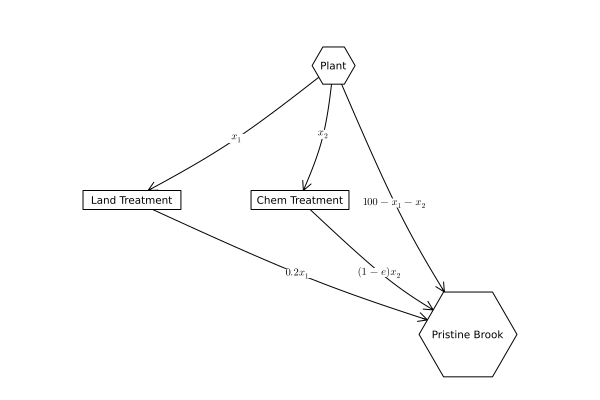

In [86]:
A = [0 1 1 1;
    0 0 0 1;
    0 0 0 1;
    0 0 0 0]

names = ["Plant", "Land Treatment", "Chem Treatment", "Pristine Brook"]
# modify this dictionary to add labels
 # old code: edge_labels = Dict((1, 2) => "", (1,3) => "", (1, 4) => "",(2, 4) => "",(3, 4) => "")
edge_labels = Dict((1, 2) => L"x_1", (1,3) => L"x_2", (1, 4) => L"100-x_1-x_2",(2, 4) => L"0.2x_1",(3, 4) => L"(1-e)x_2")
shapes=[:hexagon, :rect, :rect, :hexagon]
shapes=[:hexagon, :rect, :rect, :hexagon]
xpos = [0, -1.5, -0.25, 1]
ypos = [1, 0, 0, -1]

p = graphplot(A, names=names,edgelabel=edge_labels, markersize=0.15, markershapes=shapes, markercolor=:white, x=xpos, y=ypos)
display(p)

I added labels to the edge_labels to show each flow with units of kg/day of YUK as the concentration of YUK is 1 kg/m^3.

#### Problem 2.1

Formulate a mathematical model for the treatment cost and the amount of
YUK that will be discharged into Pristine Brook based on the wastewater
allocations. This is best done with some equations and supporting text
explaining the derivation. Make sure you include, as additional
equations in the model, any needed constraints on relevant values. You
can find some basics on writing mathematical equations using the LaTeX
typesetting syntax
[here](https://viveks.me/environmental-systems-analysis/tutorials/latex-notebook.qmd),
and a cheatsheet with LaTeX commands can be found on the course
website’s [Resources
page](https://viveks.me/environmental-systems-analysis/resources/markdown.qmd).

**Treatment cost = land treatment cost + chem treatment cost + direct disposal cost**

Treatment cost = $X_1^2/20  + 1.5X_2 + 0$

Treatment cost = $X_1^2/20  + 1.5X_2$ (dollars/day)

The total treatment cost is the sum of all three methods of treatment. As specified above, land treatment is $X_1<^2/20$ dollars/day while chemical 
treatment is $1.5X_2$ dollars/day. Direct disposal is assumed free because there is no information on cost.  

**YUK discharge = land treatment discharge + chem treatment discharge + direct discharge**

YUK discharge = $0.2X_1$ + $(1 - e)X_2$ + $(100 - X_1 - X_2)$

YUK discharge = $0.2X_1 + (1 - (1 - 0.005X_2))X_2 + (100 - X_1 - X_2)$

YUK discharge = $0.2X_1 + (0.005X_2)X_2 + (100 - X_1 - X_2)$

YUK discharge = $0.2X_1 + 0.005X_2^2 + (100 - X_1 - X_2)$

where $X_1 + X_2$ <= $100$ and YUK discharge < 20 kg/day.

The total YUK discharge is the sum of all three discharge sources. Land treatment discharges 20% of the original YUK $(0.2X_1)$. Chemical treatment discharges $(1-e)$% of the original YUK $((1-e)X_2) = 0.005X_2^2$. Direct disposal discharges the untreated portion $(100 - X_1 - X_2)$. Since influent is 1 kg/m³, discharge (m³/day) is equal to discharge (kg/day).


#### Problem 2.2

Implement your systems model as a Julia function which computes the
resulting YUK discharge and cost for a particular treatment plan. You
can return multiple values from a function with a
[tuple](https://docs.julialang.org/en/v1/manual/functions/#Tuples-1), as
in:

In [87]:
function multiple_return_values(x, y)
    return (x+y, x*y)
end

a, b = multiple_return_values(2, 5)
@show a;
@show b;

a = 7
b = 10


To evalute the function over vectors of inputs, you can *broadcast* the
function by adding a decimal `.` before the function arguments and
accessing the resulting values by writing a *comprehension* to loop over
the individual outputs in the vector:

In [88]:
x = [1, 2, 3, 4, 5]
y = [6, 7, 8, 9, 10]

output = multiple_return_values.(x, y)
a = [out[1] for out in output]
b = [out[2] for out in output]
@show a;
@show b;

a = [7, 9, 11, 13, 15]
b = [6, 14, 24, 36, 50]


In [89]:
#### Problem 2.2

# Function returns (cost $/day, YUK discharge kg/day) given X1, X2
function evaluate_plan(X1, X2)
    cost = (X1^2)/20 + 1.5*X2
    yuk  = 0.2*X1 + 0.005*X2^2 + (100 - X1 - X2)
    return (cost, yuk)
end

# Test three example allocations
@show evaluate_plan(50, 50)   # split evenly
@show evaluate_plan(10, 90)   # mostly chemical
@show evaluate_plan(0, 0)     # all direct


evaluate_plan(50, 50) = (200.0, 22.5)
evaluate_plan(10, 90) = (140.0, 42.5)
evaluate_plan(0, 0) = (0.0, 100.0)


(0.0, 100.0)

For Problem 2.2, I wrote a Julia function called evaluate_plan that takes the flows to land treatment (X1) and chemical treatment (X2) as inputs and returns a tuple containing both the treatment cost (in dollars per day) and the YUK discharge (in kilograms per day). The cost is computed using the formula 
$(X_1^2)/20  + 1.5X_2$, while the discharge is computed as $0.2X_1 + 0.005X_2^2 + (100 - X_1 - X_2)$, which represents the combined contributions from land treatment, chemical treatment, and direct discharge. I tested the function on three example plans: one with an even 50/50 split between land and chemical treatment, one with mostly chemical treatment (10/90), and one with all direct discharge (0/0). The results confirmed that the function correctly calculates both the cost and the YUK discharge for different treatment allocations.

Make sure you comment your code appropriately to make it clear what is
going on and why.

#### Problem 2.3

Use your function to experiment with 1,000 different combinations of
wastewater discharge and treatment. You can do this with either a grid
search or by sampling from a [Dirichlet
distribution](https://en.wikipedia.org/wiki/Dirichlet_distribution) (a
$\text{Dirichlet}(1, n)$ distribution will generate uniformly-weighted
$n$-dimensional vectors whose components add up to 1; see the
[`Distributions.jl`
documentation](https://juliastats.org/Distributions.jl/stable/starting/)
for how to sample from probability distributions in Julia). Plot the
results of these experiments. Do any satisfy the YUK effluent standard
(plot this as well as a dashed red line). What was the cost of solutions
satisfying the standard? What can you say about the tradeoff between
treatment cost and YUK discharge? You don’t have to find an “optimal”
solution to this problem, but what do you think would be needed to find
a better solution?

#### Problem 2.4

Find the strategies which minimize cost and YUK discharge (these will be
different strategies) analytically and find the values of the objective
metrics. Plot these values in the plot that you created for Problem 2.3.
How do their values compare to the spread of values that you found in
that problem? Would you select either of them (explain why or why not)?

## References

List any external references consulted, including classmates.

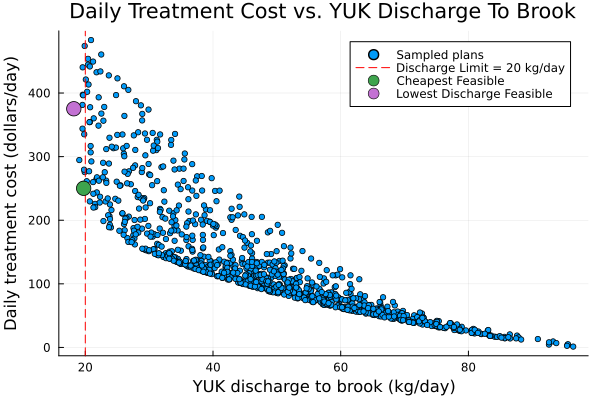

Results for Lowest Cost Plan:
z = 19.744 kg/day
c = 250.2 dollar/day
Results for Lowest Discharge Plan:
z = 18.2 kg/day
c = 375.23 dollar/day
random seed = 77


In [115]:
#### Problem 2.3

using Distributions, Random, Plots

# --- Model: given flows to land (x1), chemical (x2), direct (x3)
# Returns (discharge_kg_per_day, cost_dollars_per_day, is_feasible)
# From 2.1:  cost = x1^2/20 + 1.5*x2
#            discharge = 0.2*x1 + 0.005*x2^2 + x3
# Feasibility = (discharge ≤ 20)
function model(x1::Real, x2::Real, x3::Real)
    z = 0.2*x1 + 0.005*x2^2 + x3             # YUK to brook (kg/day)
    c = (x1^2)/20 + 1.5*x2                   # daily cost ($/day)
    return (z, c, z <= 20)
end

# --- Sampling setup
seed = rand(1:100)           # random seed (recorded below)
Random.seed!(seed)

Q = 100.0                     # total flow (m^3/day)
n = 1000                      # number of combinations

# Dirichlet over 3 parts; each column sums to 1 -> scale by Q
d  = Dirichlet(ones(3))
X  = Q .* rand(d, n)          # 3×n matrix

# Evaluate all plans
results = [model(X[1,j], X[2,j], X[3,j]) for j in 1:n]

# Unpack tuples
z = first.(results)                 # discharge (kg/day)
c = getindex.(results, 2)           # cost ($/day)
feasibility = getindex.(results, 3) # Bool

# Feasible set indices
feasible = findall(feasibility)

# Report cheapest feasible and lowest-discharge feasible (if any)
if !isempty(feasible)
    min_idxc = feasible[argmin(c[feasible])]  # cheapest feasible
    println("Results for Lowest Cost Plan:")
    println("z = $(round(z[min_idxc], digits=3)) kg/day")
    println("c = $(round(c[min_idxc], digits=2)) dollar/day")

    min_idxz = feasible[argmin(z[feasible])]  # lowest discharge feasible
    println("Results for Lowest Discharge Plan:")
    println("z = $(round(z[min_idxz], digits=3)) kg/day")
    println("c = $(round(c[min_idxz], digits=2)) dollar/day")
else
    @warn "No feasible plans (z ≤ 20 kg/day) found in this sample."
end

println("random seed = $seed")

# --- Plot: cost vs discharge
plt = scatter(
    z, c;
    xlabel = "YUK discharge to brook (kg/day)",
    ylabel = "Daily treatment cost (dollars/day)",
    title  = "Daily Treatment Cost vs. YUK Discharge To Brook",
    label  = "Sampled plans",
    legend = :topright,
    ms = 3
)

# vertical effluent limit at 20 kg/day
vline!(plt, [20.0]; lc = :red, ls = :dash, label = "Discharge Limit = 20 kg/day")

# highlight the two special feasible plans (if they exist)
if !isempty(feasible)
    scatter!(plt, [z[min_idxc]], [c[min_idxc]]; ms=8, label="Cheapest Feasible")
    scatter!(plt, [z[min_idxz]], [c[min_idxz]]; ms=8, label="Lowest Discharge Feasible")
end

display(plt)




For Problem 2.3, I created a Julia function called model that takes in the flows to land treatment , chemical treatment (x2), and direct discharge (x3) and returns the YUK discharge, treatment cost, and whether the plan is feasible (i.e., discharge ≤ 20 kg/day). Using the Dirichlet distribution, I generated 1,000 random allocations of the 100 m³/day wastewater among the three options, ensuring that the flows always sum to the total. For each plan, I calculated the discharge and cost, then identified the subset of plans that met the effluent standard. I reported both the cheapest feasible plan (minimum cost while satisfying the limit) and the lowest-discharge feasible plan. Finally, I plotted all sampled plans as a scatter plot of cost versus discharge, added a vertical dashed line at the 20 kg/day standard, and highlighted the two special feasible plans on the graph. This experiment shows the tradeoff between cost and discharge, with low-cost plans generally producing higher discharges, and feasible plans clustering at higher costs.

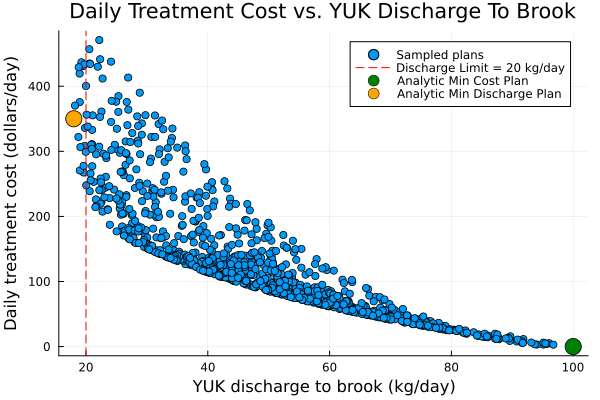

random seed = 81
Number of feasible plans = 16


In [116]:
#### Problem 2.4
using Distributions, Random, Plots

# set random seed for data generation
seed = rand(1:100)
Random.seed!(seed)

Q = 100.0                       # flow
n = 1000                        # number of combinations

# vector whose elements sum to Q
d  = Dirichlet(ones(3))
# sample n from the Dirichlet distribution and scale by Q
X = Q .* rand(d, n)  

# Define model: return (discharge, cost, feasible?)
model(x1, x2, x3) = begin
    discharge = 0.2*x1 + 0.005*x2^2 + x3
    cost = (x1^2)/20 + 1.5*x2
    feasible = discharge <= 20
    return (discharge, cost, feasible)
end

# results of each plan
results = [model(X[1,j], X[2,j], X[3,j]) for j in 1:n]

# unpack tuples into vectors
z = first.(results)                         # discharge
c = getindex.(results, 2)                   # cost
feasibility = getindex.(results, 3)         # feasibility

# summarize feasible set
feasible = findall(feasibility)
println("random seed = $seed")
println("Number of feasible plans = ", length(feasible))

# plot cost vs discharge
plt = scatter(z, c; xlabel = "YUK discharge to brook (kg/day)",
    ylabel = "Daily treatment cost (dollars/day)",
    title  = "Daily Treatment Cost vs. YUK Discharge To Brook",
    label = "Sampled plans", legend = :topright)

# vertical line showing the maximum allowable discharge of 20
vline!(plt, [20.0]; lc = :red, ls = :dash, label = "Discharge Limit = 20 kg/day")

# add analytic points
scatter!(plt, [100.0], [0.0]; ms=9, c=:green, label="Analytic Min Cost Plan")
scatter!(plt, [18.0], [350.0]; ms=9, c=:orange, label="Analytic Min Discharge Plan")

# plot
display(plt)


For Problem 2.4, I analytically identified the two extreme strategies and overlaid them on a scatter plot of 1,000 randomly sampled treatment plans. The code samples feasible allocations with a Dirichlet distribution (flows sum to 100 m³/day), computes each plan’s YUK discharge and daily cost with model, and marks plans that satisfy the effluent limit (≤ 20 kg/day). I then added the analytic minimum-cost point, which sends all flow directly to the brook (𝑥1 = 0,𝑥2 = 0,𝑥3 = 100) (x1 = 0,x2 = 0,x3 = 100) and therefore has cost = $0/day and discharge = 100 kg/day (not feasible), and the analytic minimum-discharge point (𝑥1 = 80,𝑥2 = 20,𝑥3 = 0) (x1 = 80,x2 ​= 20,x3 ​= 0) with discharge = 18 kg/day and cost = $350/day (feasible). The plot makes the tradeoff clear: achieving very low discharge requires substantially higher cost. Comparing these extremes to the random cloud, the min-cost plan is unacceptable because it violates the standard, while the min-discharge plan is safe but expensive. A more practical choice would be the cheapest feasible plan near the 20 kg/day boundary, which could be found more reliably with a constrained optimization approach rather than random sampling.